# 🧳 Clarity Travel Technology — Data Science Assessment
## Part 1: Exploratory Data Analysis & Business Insights

**Candidate Notebook** | Dataset: `clarity_bookings_dataset.csv` | 2,000 booking records

---


## 0. Setup — Import Libraries & Load Data

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


In [2]:
# Load the dataset
# NOTE: This notebook lives in Part1_EDA/ and the data is in ../data/
df = pd.read_csv('../data/clarity_bookings_dataset.csv')

print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


✅ Dataset loaded: 2000 rows × 23 columns


,booking_id,booking_date,departure_date,lead_time_days,airline,origin,destination,haul_type,cabin_class,trip_type,...,pax_count,base_fare_inr,taxes_inr,total_fare_inr,ancillary_revenue_inr,payment_method,prior_bookings,booking_status,customer_complaint,satisfaction_score
0,CLR-00001,2025-11-24,2025-12-09,15,Air Canada,DEL,LHR,Long-Haul,Economy,Round-Trip,...,2,18788.67,1749.55,41076.44,NaN,Credit Card,0,Ticketed,NaN,5.0
1,CLR-00002,2025-06-24,2025-07-30,36,Condor,BLR,FRA,Long-Haul,First,One-Way,...,3,286719.58,52229.54,1016847.36,9372.39,Agent Credit,0,Cancelled,NaN,NaN
2,CLR-00003,2025-05-29,2025-06-09,11,KLM,DEL,JFK,Long-Haul,Economy,One-Way,...,1,43848.08,7703.96,51552.04,0.00,Credit Card,0,Ticketed,NaN,5.0
3,CLR-00004,2025-04-28,2025-08-12,106,American Airlines,BOM,DXB,Medium-Haul,Economy,Round-Trip,...,3,19142.46,2591.67,65202.39,6750.15,Credit Card,0,Ticketed,NaN,5.0
4,CLR-00005,2025-01-25,2025-05-16,111,Etihad Airways,DEL,CDG,Long-Haul,Premium Economy,One-Way,...,1,67299.98,14533.50,81833.48,0.00,Credit Card,1,Ticketed,NaN,4.0


---
## 1. Data Quality — Missing Values & Assumptions

Before any analysis, we inspect and clean the data.


In [3]:
# ── 1a. Basic info ──
print("=== DATASET INFO ===")
df.info()


=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   booking_id             2000 non-null   str    
 1   booking_date           2000 non-null   str    
 2   departure_date         2000 non-null   str    
 3   lead_time_days         2000 non-null   int64  
 4   airline                2000 non-null   str    
 5   origin                 2000 non-null   str    
 6   destination            2000 non-null   str    
 7   haul_type              2000 non-null   str    
 8   cabin_class            2000 non-null   str    
 9   trip_type              2000 non-null   str    
 10  fare_basis             1959 non-null   str    
 11  booking_channel        2000 non-null   str    
 12  booking_source         2000 non-null   str    
 13  pax_count              2000 non-null   int64  
 14  base_fare_inr          2000 non-null   float64

=== MISSING VALUES ===
                       Missing Count  Missing %
customer_complaint              1752      87.60
satisfaction_score               263      13.15
payment_method                   104       5.20
ancillary_revenue_inr             55       2.75
fare_basis                        41       2.05


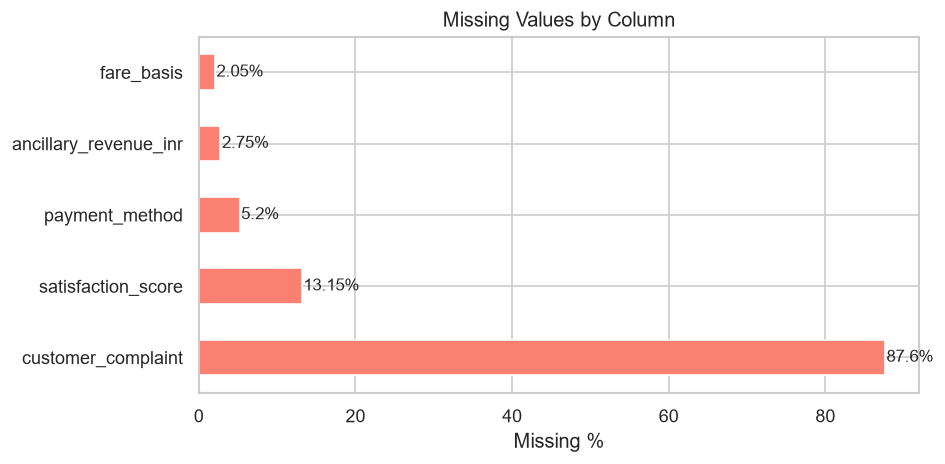

In [4]:
# ── 1b. Missing value summary ──
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("=== MISSING VALUES ===")
print(missing_df)

# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
missing_df['Missing %'].plot(kind='barh', ax=ax, color='salmon', edgecolor='white')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column')
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.2, i, f'{v}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight')
plt.show()


In [5]:
# ── 1c. Fix data types & handle missing values ──

# 1. Parse dates
df['booking_date']   = pd.to_datetime(df['booking_date'])
df['departure_date'] = pd.to_datetime(df['departure_date'])

# 2. Extract useful time features
df['booking_month']     = df['booking_date'].dt.month
df['booking_month_name']= df['booking_date'].dt.strftime('%b')
df['booking_quarter']   = df['booking_date'].dt.quarter

# 3. Fill ancillary_revenue_inr — missing likely means ₹0 ancillary
df['ancillary_revenue_inr'] = df['ancillary_revenue_inr'].fillna(0)

# 4. Fill fare_basis with 'Unknown'
df['fare_basis'] = df['fare_basis'].fillna('Unknown')

# 5. Fill payment_method with mode (most common)
df['payment_method'] = df['payment_method'].fillna(df['payment_method'].mode()[0])

# 6. satisfaction_score — keep NaN for now; we will exclude in score-based analysis
# (missing scores are mostly for cancelled/refunded bookings — not random)

# 7. customer_complaint — missing = no complaint (most bookings fine)
df['has_complaint'] = df['customer_complaint'].notna().astype(int)

print("✅ Data types fixed and missing values handled")
print(f"   • ancillary_revenue_inr nulls filled with 0: {df['ancillary_revenue_inr'].isnull().sum()}")
print(f"   • fare_basis nulls filled with 'Unknown': {(df['fare_basis']=='Unknown').sum()}")
print(f"   • payment_method nulls filled with mode: {df['payment_method'].isnull().sum()}")
print(f"   • satisfaction_score nulls kept: {df['satisfaction_score'].isnull().sum()} (will exclude in scoring analysis)")


✅ Data types fixed and missing values handled
   • ancillary_revenue_inr nulls filled with 0: 0
   • fare_basis nulls filled with 'Unknown': 41
   • payment_method nulls filled with mode: 0
   • satisfaction_score nulls kept: 263 (will exclude in scoring analysis)


### 📋 Data Quality Summary

| Column | Missing | Action Taken |
|--------|---------|-------------|
| `customer_complaint` | 87.6% | Expected — most bookings have no complaint. Created `has_complaint` flag. |
| `satisfaction_score` | 13.2% | Concentrated in Cancelled/Refunded rows. Excluded from score analysis. |
| `payment_method` | 5.2% | Filled with mode (most frequent value). |
| `ancillary_revenue_inr` | 2.75% | Filled with ₹0 — no ancillary purchased. |
| `fare_basis` | 2.05% | Filled with 'Unknown'. |

**Assumptions:**
- `total_fare_inr` already includes pax_count multiplication (verified by spot-checking rows).
- Satisfaction scores missing on cancelled bookings are **not random** — likely disengaged customers.
- `prior_bookings = 0` means a new customer; `> 0` means a repeat customer.


---
## 2. Revenue Analysis

### Questions answered:
- Top revenue-generating airlines, routes, and cabin classes?
- How does revenue distribute across NDC vs GDS?


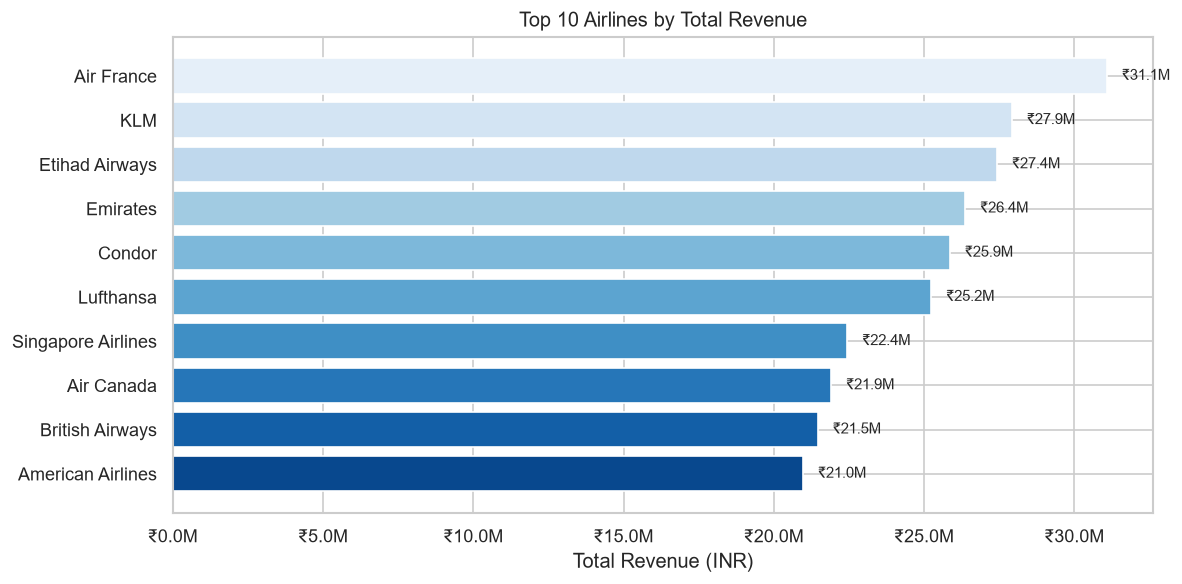

           Airline  Total Revenue (INR)
        Air France           31079227.0
               KLM           27917987.0
    Etihad Airways           27422623.0
          Emirates           26363326.0
            Condor           25853898.0
         Lufthansa           25233232.0
Singapore Airlines           22440270.0
        Air Canada           21903023.0
   British Airways           21458251.0
 American Airlines           20966839.0


In [6]:
# ── 2a. Total revenue by airline ──
airline_rev = (
    df.groupby('airline')['total_fare_inr']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
airline_rev.columns = ['Airline', 'Total Revenue (INR)']
airline_rev['Total Revenue (INR)'] = airline_rev['Total Revenue (INR)'].round(0)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(airline_rev['Airline'][::-1], airline_rev['Total Revenue (INR)'][::-1],
               color=sns.color_palette("Blues_r", 10))
ax.set_xlabel('Total Revenue (INR)')
ax.set_title('Top 10 Airlines by Total Revenue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
for bar, val in zip(bars, airline_rev['Total Revenue (INR)'][::-1]):
    ax.text(val + 5e5, bar.get_y() + bar.get_height()/2,
            f'₹{val/1e6:.1f}M', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('revenue_by_airline.png', bbox_inches='tight')
plt.show()

print(airline_rev.to_string(index=False))


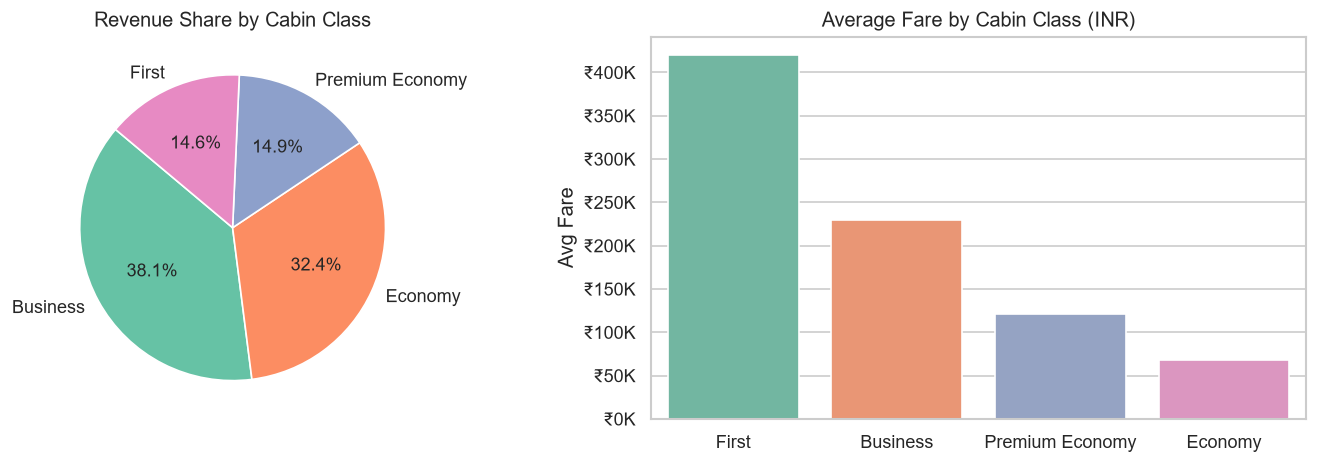

    Cabin Class  Total Revenue  Avg Fare  Bookings
       Business     95565010.0  229173.0       417
        Economy     81100090.0   68324.0      1187
Premium Economy     37410067.0  121068.0       309
          First     36563509.0  420270.0        87


In [7]:
# ── 2b. Revenue by cabin class ──
cabin_rev = df.groupby('cabin_class')['total_fare_inr'].agg(['sum','mean','count']).reset_index()
cabin_rev.columns = ['Cabin Class', 'Total Revenue', 'Avg Fare', 'Bookings']
cabin_rev = cabin_rev.sort_values('Total Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Total revenue pie
axes[0].pie(cabin_rev['Total Revenue'], labels=cabin_rev['Cabin Class'],
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette("Set2", len(cabin_rev)))
axes[0].set_title('Revenue Share by Cabin Class')

# Average fare bar
sns.barplot(data=cabin_rev, x='Cabin Class', y='Avg Fare', ax=axes[1],
            palette='Set2', order=cabin_rev.sort_values('Avg Fare', ascending=False)['Cabin Class'])
axes[1].set_title('Average Fare by Cabin Class (INR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e3:.0f}K'))
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('revenue_by_cabin.png', bbox_inches='tight')
plt.show()

print(cabin_rev.round(0).to_string(index=False))


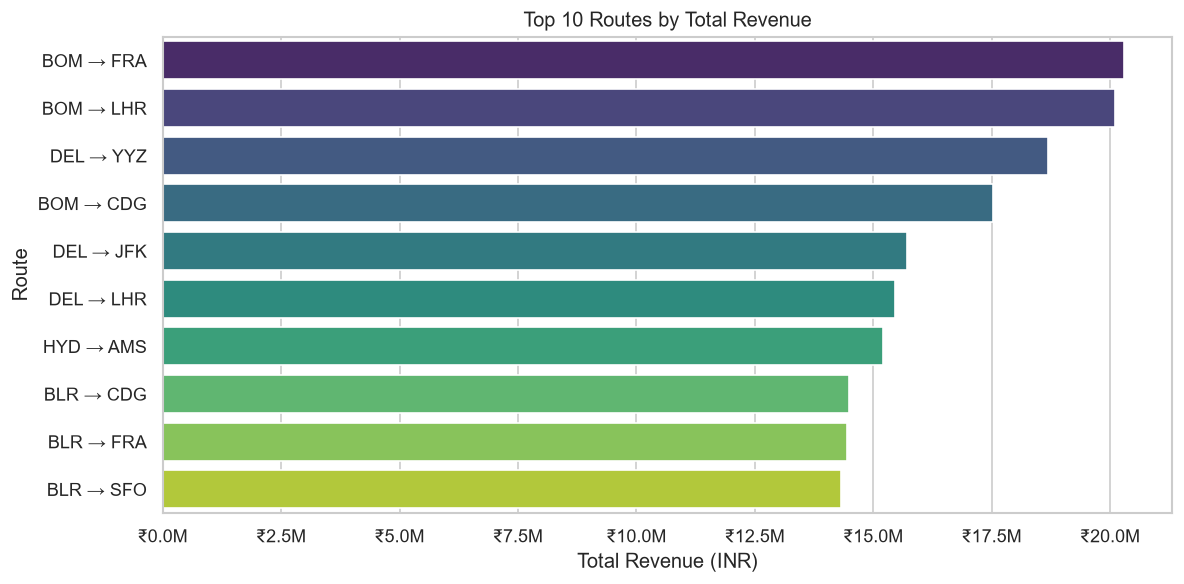

In [8]:
# ── 2c. Top 10 routes by revenue ──
df['route'] = df['origin'] + ' → ' + df['destination']
route_rev = (
    df.groupby('route')['total_fare_inr']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
route_rev.columns = ['Route', 'Total Revenue']

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=route_rev, y='Route', x='Total Revenue', palette='viridis', ax=ax)
ax.set_title('Top 10 Routes by Total Revenue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax.set_xlabel('Total Revenue (INR)')
plt.tight_layout()
plt.savefig('revenue_by_route.png', bbox_inches='tight')
plt.show()


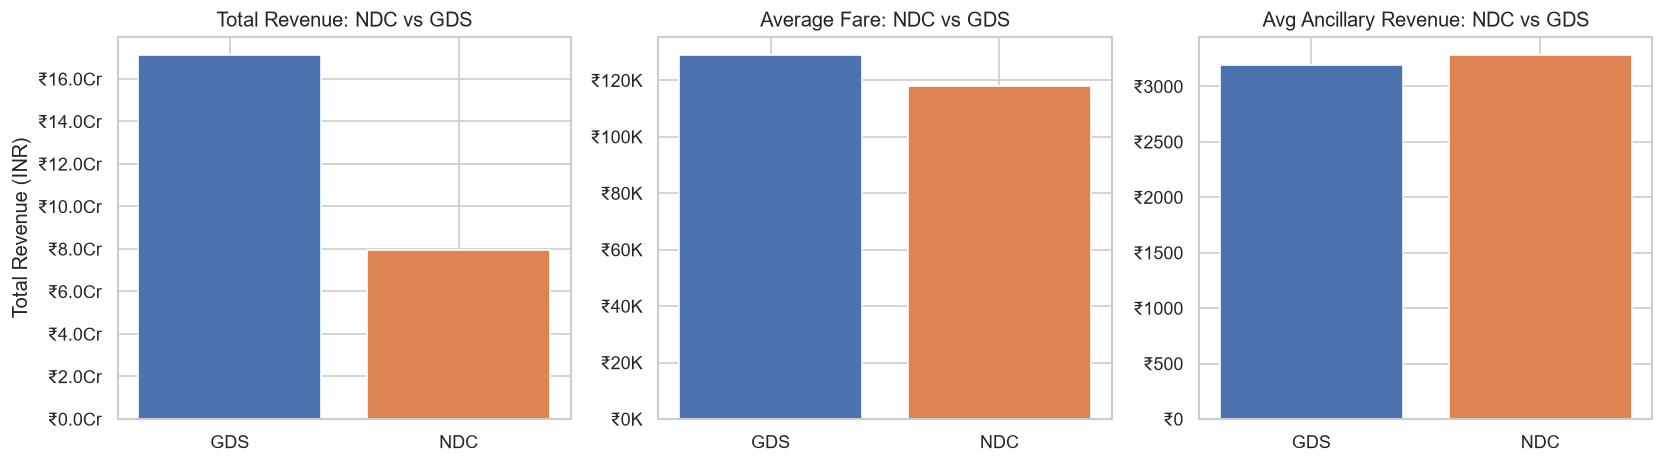

booking_source  total_revenue  avg_fare  bookings  avg_ancillary  revenue_share_%
           GDS    171319740.0  129006.0      1328         3194.0             68.0
           NDC     79318936.0  118034.0       672         3284.0             32.0


In [9]:
# ── 2d. NDC vs GDS revenue comparison ──
source_rev = df.groupby('booking_source').agg(
    total_revenue=('total_fare_inr', 'sum'),
    avg_fare=('total_fare_inr', 'mean'),
    bookings=('booking_id', 'count'),
    avg_ancillary=('ancillary_revenue_inr', 'mean')
).reset_index()
source_rev['revenue_share_%'] = (source_rev['total_revenue'] / source_rev['total_revenue'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

colors = ['#4C72B0', '#DD8452']

axes[0].bar(source_rev['booking_source'], source_rev['total_revenue'], color=colors)
axes[0].set_title('Total Revenue: NDC vs GDS')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e7:.1f}Cr'))
axes[0].set_ylabel('Total Revenue (INR)')

axes[1].bar(source_rev['booking_source'], source_rev['avg_fare'], color=colors)
axes[1].set_title('Average Fare: NDC vs GDS')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e3:.0f}K'))

axes[2].bar(source_rev['booking_source'], source_rev['avg_ancillary'], color=colors)
axes[2].set_title('Avg Ancillary Revenue: NDC vs GDS')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.0f}'))

for ax in axes:
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig('ndc_vs_gds_revenue.png', bbox_inches='tight')
plt.show()

print(source_rev.round(0).to_string(index=False))


---
## 3. Cancellation Patterns

**Binary target definition:** `is_cancelled = 1` if status is Cancelled or Refunded, else 0.


Total bookings       : 2,000
Cancelled/Refunded   : 451
Overall cancel rate  : 22.6%

Booking Status Breakdown:
booking_status
Ticketed     1076
Confirmed     422
Cancelled     276
Refunded      175
No-Show        51


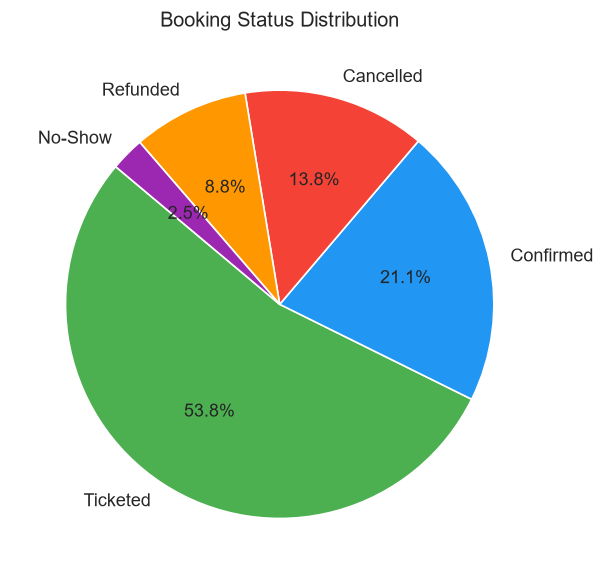

In [10]:
# ── 3a. Overall cancellation rate ──
df['is_cancelled'] = df['booking_status'].isin(['Cancelled', 'Refunded']).astype(int)

total = len(df)
cancelled = df['is_cancelled'].sum()
rate = cancelled / total * 100

print(f"Total bookings       : {total:,}")
print(f"Cancelled/Refunded   : {cancelled:,}")
print(f"Overall cancel rate  : {rate:.1f}%")
print()
print("Booking Status Breakdown:")
print(df['booking_status'].value_counts().to_string())

# Status distribution pie
fig, ax = plt.subplots(figsize=(7, 5))
status_counts = df['booking_status'].value_counts()
colors_pie = ['#4CAF50','#2196F3','#F44336','#FF9800','#9C27B0']
ax.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
       colors=colors_pie, startangle=140)
ax.set_title('Booking Status Distribution')
plt.tight_layout()
plt.savefig('booking_status_distribution.png', bbox_inches='tight')
plt.show()


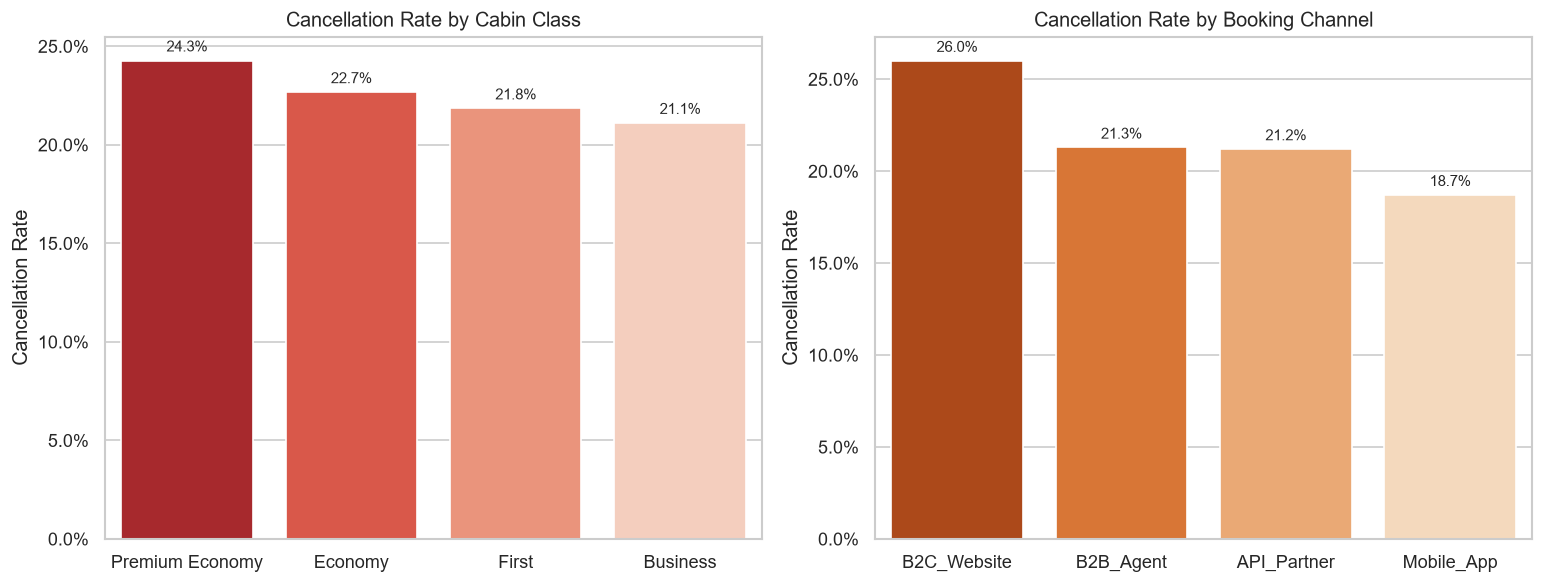

In [11]:
# ── 3b. Cancellation rate by cabin class & booking channel ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# By cabin class
cabin_cancel = df.groupby('cabin_class')['is_cancelled'].mean().sort_values(ascending=False).reset_index()
cabin_cancel['cancel_rate_%'] = (cabin_cancel['is_cancelled'] * 100).round(1)
sns.barplot(data=cabin_cancel, x='cabin_class', y='is_cancelled', ax=axes[0],
            palette='Reds_r', order=cabin_cancel['cabin_class'])
axes[0].set_title('Cancellation Rate by Cabin Class')
axes[0].set_ylabel('Cancellation Rate')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].set_xlabel('')
for bar, val in zip(axes[0].patches, cabin_cancel['cancel_rate_%']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val}%', ha='center', va='bottom', fontsize=9)

# By booking channel
channel_cancel = df.groupby('booking_channel')['is_cancelled'].mean().sort_values(ascending=False).reset_index()
channel_cancel['cancel_rate_%'] = (channel_cancel['is_cancelled'] * 100).round(1)
sns.barplot(data=channel_cancel, x='booking_channel', y='is_cancelled', ax=axes[1],
            palette='Oranges_r')
axes[1].set_title('Cancellation Rate by Booking Channel')
axes[1].set_ylabel('Cancellation Rate')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_xlabel('')
for bar, val in zip(axes[1].patches, channel_cancel['cancel_rate_%']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('cancellation_by_cabin_channel.png', bbox_inches='tight')
plt.show()


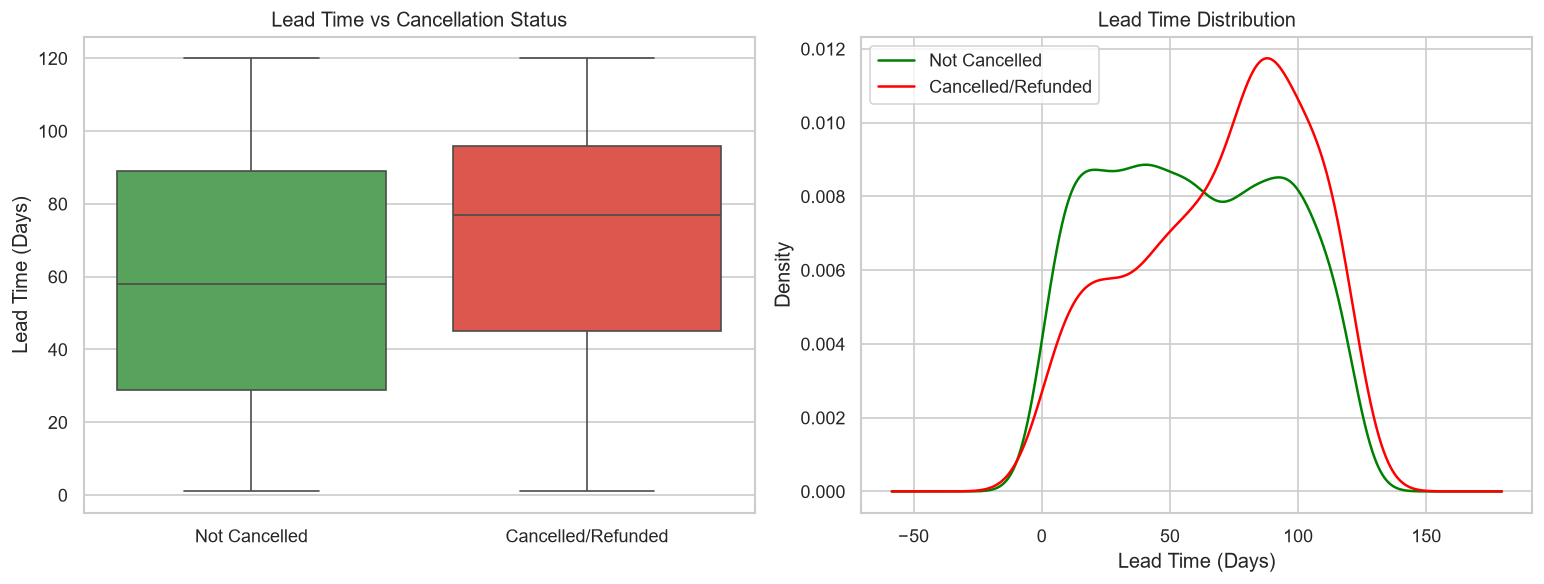

Mean lead time — Not Cancelled: 58.8
Mean lead time — Cancelled    : 69.7


In [12]:
# ── 3c. Lead time vs cancellation (box + distribution) ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
sns.boxplot(data=df, x='is_cancelled', y='lead_time_days',
            palette=['#4CAF50','#F44336'], ax=axes[0])
axes[0].set_xticklabels(['Not Cancelled', 'Cancelled/Refunded'])
axes[0].set_title('Lead Time vs Cancellation Status')
axes[0].set_ylabel('Lead Time (Days)')
axes[0].set_xlabel('')

# KDE
df[df['is_cancelled']==0]['lead_time_days'].plot.kde(ax=axes[1], label='Not Cancelled', color='green')
df[df['is_cancelled']==1]['lead_time_days'].plot.kde(ax=axes[1], label='Cancelled/Refunded', color='red')
axes[1].set_title('Lead Time Distribution')
axes[1].set_xlabel('Lead Time (Days)')
axes[1].legend()

plt.tight_layout()
plt.savefig('lead_time_vs_cancellation.png', bbox_inches='tight')
plt.show()

print("Mean lead time — Not Cancelled:", df[df['is_cancelled']==0]['lead_time_days'].mean().round(1))
print("Mean lead time — Cancelled    :", df[df['is_cancelled']==1]['lead_time_days'].mean().round(1))


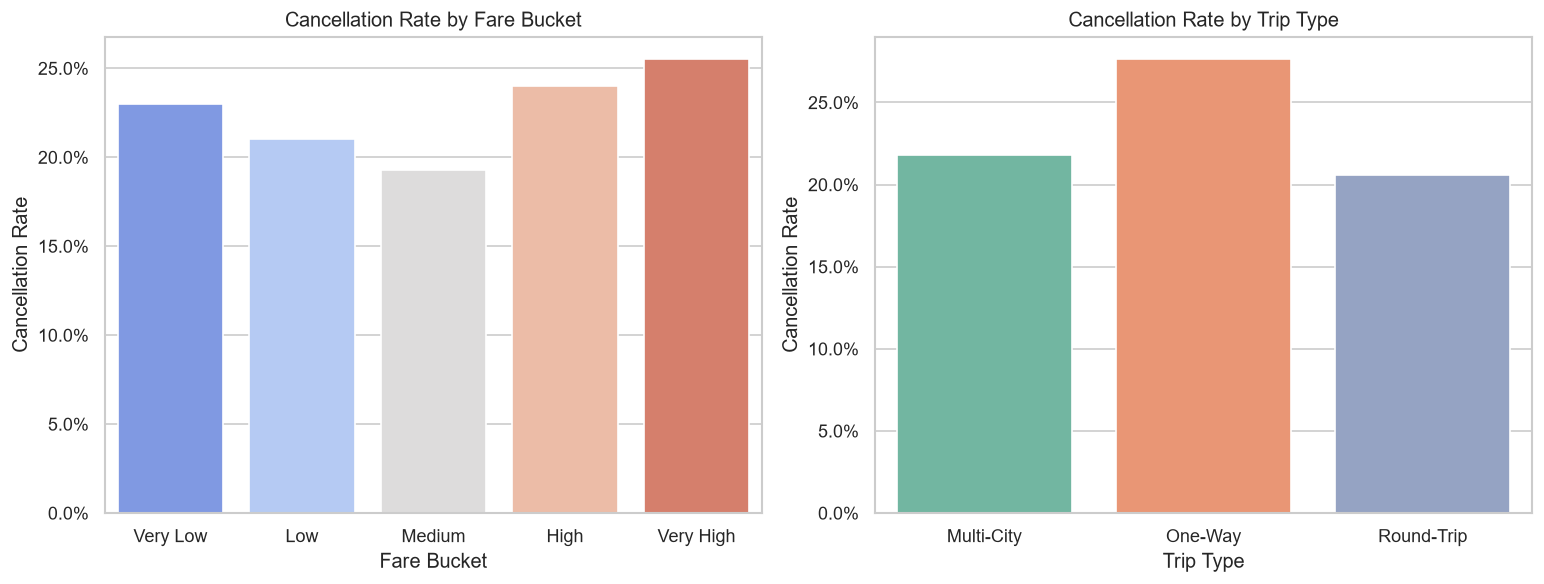

In [13]:
# ── 3d. Cancellation rate by fare amount bucket & trip type ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Fare buckets
df['fare_bucket'] = pd.qcut(df['total_fare_inr'], q=5,
                             labels=['Very Low','Low','Medium','High','Very High'])
fare_cancel = df.groupby('fare_bucket', observed=True)['is_cancelled'].mean().reset_index()
sns.barplot(data=fare_cancel, x='fare_bucket', y='is_cancelled', ax=axes[0], palette='coolwarm')
axes[0].set_title('Cancellation Rate by Fare Bucket')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].set_xlabel('Fare Bucket')
axes[0].set_ylabel('Cancellation Rate')

# Trip type
trip_cancel = df.groupby('trip_type')['is_cancelled'].mean().reset_index()
sns.barplot(data=trip_cancel, x='trip_type', y='is_cancelled', ax=axes[1], palette='Set2')
axes[1].set_title('Cancellation Rate by Trip Type')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_xlabel('Trip Type')
axes[1].set_ylabel('Cancellation Rate')

plt.tight_layout()
plt.savefig('cancellation_fare_triptype.png', bbox_inches='tight')
plt.show()


---
## 4. Booking Trends — Seasonal & Monthly Patterns


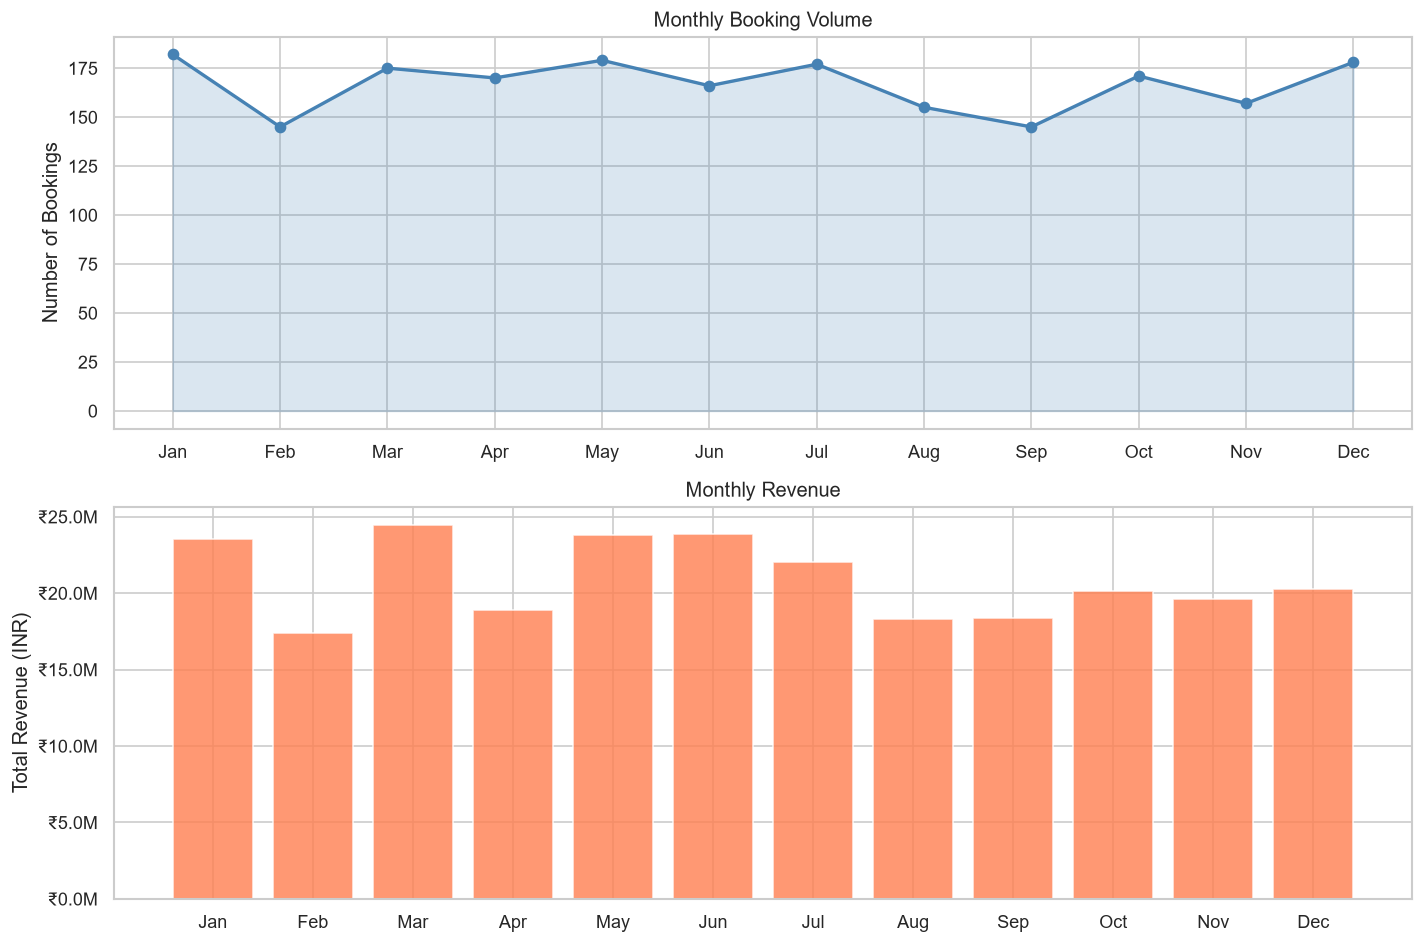

In [14]:
# ── 4a. Monthly booking volume & revenue ──
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('booking_month_name').agg(
    bookings=('booking_id','count'),
    revenue=('total_fare_inr','sum'),
    cancel_rate=('is_cancelled','mean')
).reindex(month_order).reset_index()
monthly.columns = ['Month','Bookings','Revenue','Cancel Rate']

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Bookings trend
axes[0].plot(monthly['Month'], monthly['Bookings'], marker='o', color='steelblue', linewidth=2)
axes[0].fill_between(monthly['Month'], monthly['Bookings'], alpha=0.2, color='steelblue')
axes[0].set_title('Monthly Booking Volume')
axes[0].set_ylabel('Number of Bookings')
axes[0].set_xlabel('')

# Revenue trend
axes[1].bar(monthly['Month'], monthly['Revenue'], color='coral', alpha=0.8)
axes[1].set_title('Monthly Revenue')
axes[1].set_ylabel('Total Revenue (INR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('monthly_trends.png', bbox_inches='tight')
plt.show()


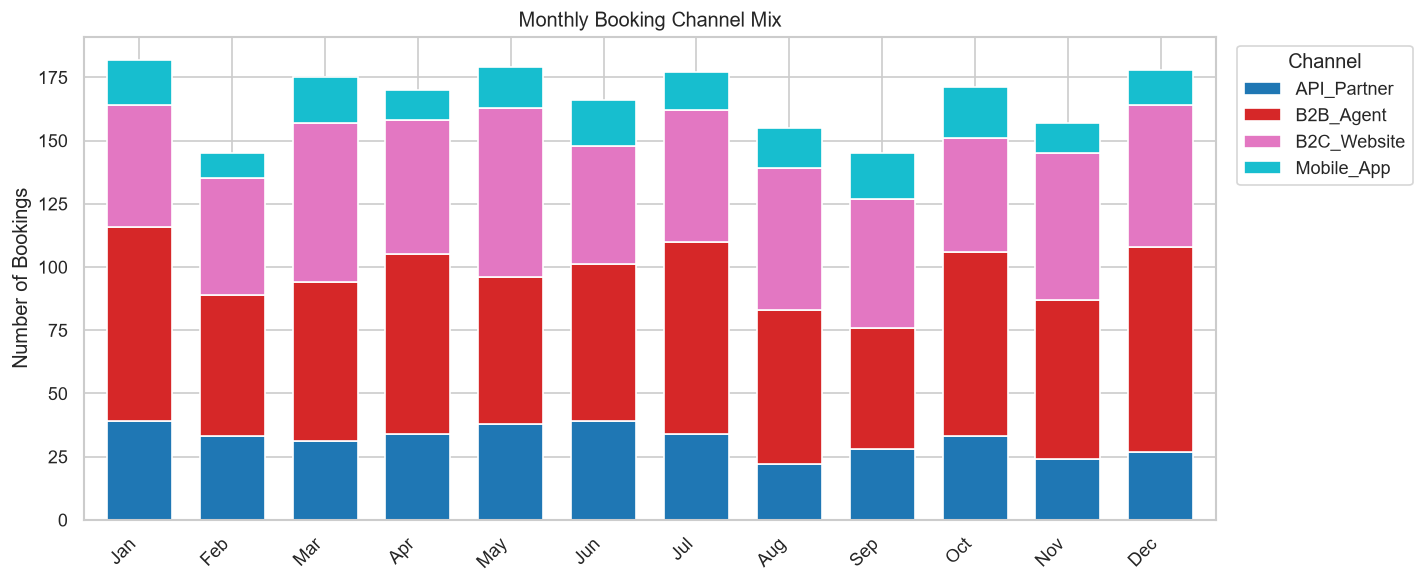

In [15]:
# ── 4b. Booking channel mix over months ──
channel_monthly = df.groupby(['booking_month_name','booking_channel'])['booking_id'].count().reset_index()
channel_monthly.columns = ['Month','Channel','Bookings']
channel_pivot = channel_monthly.pivot(index='Month', columns='Channel', values='Bookings').reindex(month_order).fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))
channel_pivot.plot(kind='bar', stacked=True, ax=ax,
                   colormap='tab10', edgecolor='white', width=0.7)
ax.set_title('Monthly Booking Channel Mix')
ax.set_ylabel('Number of Bookings')
ax.set_xlabel('')
ax.legend(title='Channel', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticklabels(month_order, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('channel_mix_monthly.png', bbox_inches='tight')
plt.show()


---
## 5. Customer Behaviour — New vs Repeat Customers


In [16]:
# ── 5a. Segment customers ──
df['customer_type'] = df['prior_bookings'].apply(lambda x: 'Repeat' if x > 0 else 'New')

# Summary stats
cust_summary = df.groupby('customer_type').agg(
    count=('booking_id','count'),
    avg_fare=('total_fare_inr','mean'),
    cancel_rate=('is_cancelled','mean'),
    avg_satisfaction=('satisfaction_score','mean'),
    avg_prior_bookings=('prior_bookings','mean')
).reset_index()

print("=== New vs Repeat Customer Summary ===")
print(cust_summary.round(2).to_string(index=False))


=== New vs Repeat Customer Summary ===
customer_type  count  avg_fare  cancel_rate  avg_satisfaction  avg_prior_bookings
          New   1285 129412.67         0.24              3.66                 0.0
       Repeat    715 117962.79         0.20              3.72                10.6


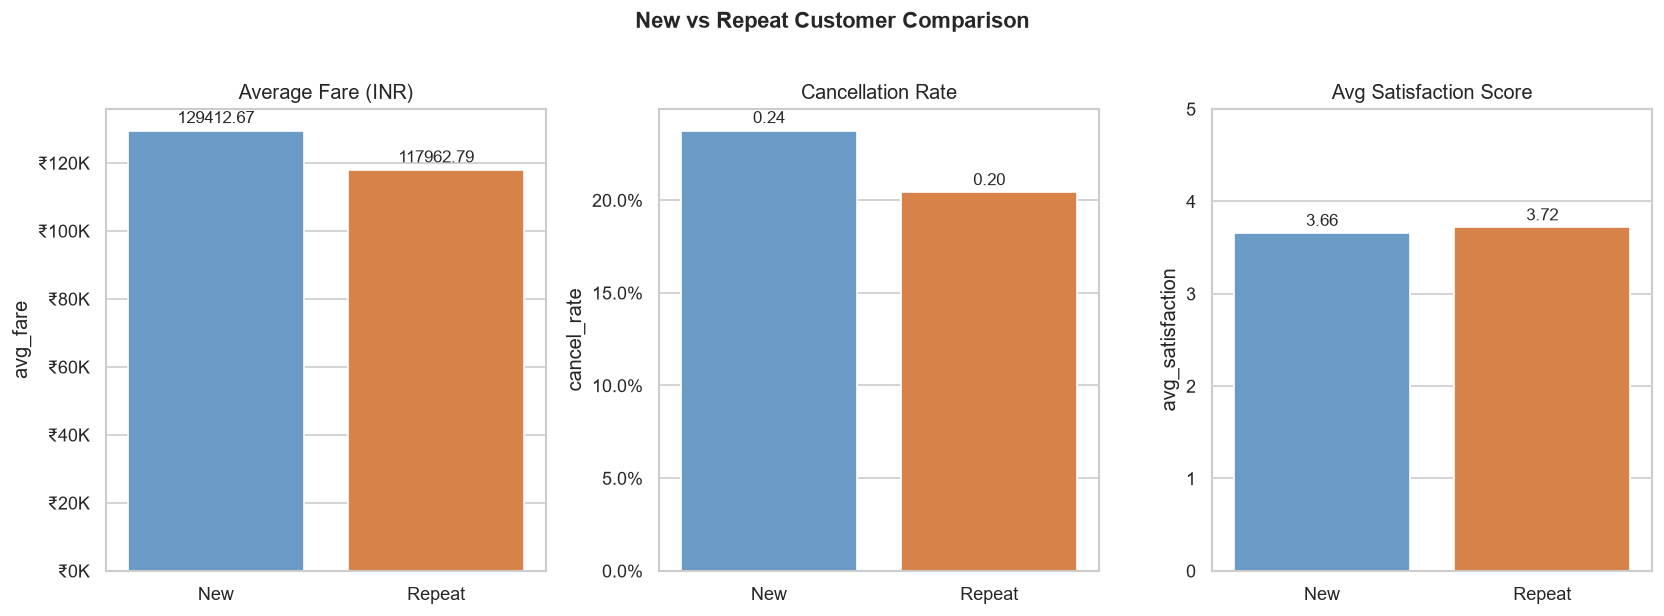

In [17]:
# ── 5b. Visual comparison: Fare, Cancellation, Satisfaction ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
palette = {'New':'#5B9BD5', 'Repeat':'#ED7D31'}

# Avg fare
sns.barplot(data=cust_summary, x='customer_type', y='avg_fare', ax=axes[0], hue='customer_type', palette=palette, legend=False)
axes[0].set_title('Average Fare (INR)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e3:.0f}K'))
axes[0].set_xlabel('')

# Cancellation rate
sns.barplot(data=cust_summary, x='customer_type', y='cancel_rate', ax=axes[1], hue='customer_type', palette=palette, legend=False)
axes[1].set_title('Cancellation Rate')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_xlabel('')

# Avg satisfaction
sns.barplot(data=cust_summary, x='customer_type', y='avg_satisfaction', ax=axes[2], hue='customer_type', palette=palette, legend=False)
axes[2].set_title('Avg Satisfaction Score')
axes[2].set_xlabel('')
axes[2].set_ylim(0, 5)

for ax in axes:
    for bar in ax.patches:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01*h,
                f'{h:.2f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('New vs Repeat Customer Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('new_vs_repeat_customers.png', bbox_inches='tight')
plt.show()


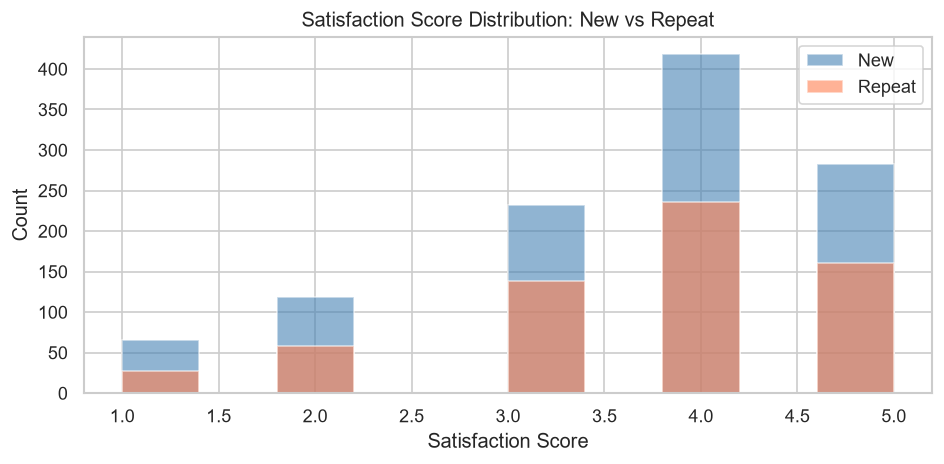

In [18]:
# ── 5c. Satisfaction score distribution ──
fig, ax = plt.subplots(figsize=(8, 4))
for ctype, color in [('New','steelblue'),('Repeat','coral')]:
    subset = df[df['customer_type']==ctype]['satisfaction_score'].dropna()
    ax.hist(subset, bins=10, alpha=0.6, label=ctype, color=color, edgecolor='white')
ax.set_title('Satisfaction Score Distribution: New vs Repeat')
ax.set_xlabel('Satisfaction Score')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('satisfaction_distribution.png', bbox_inches='tight')
plt.show()


---
## 6. Correlation Overview — Numeric Features


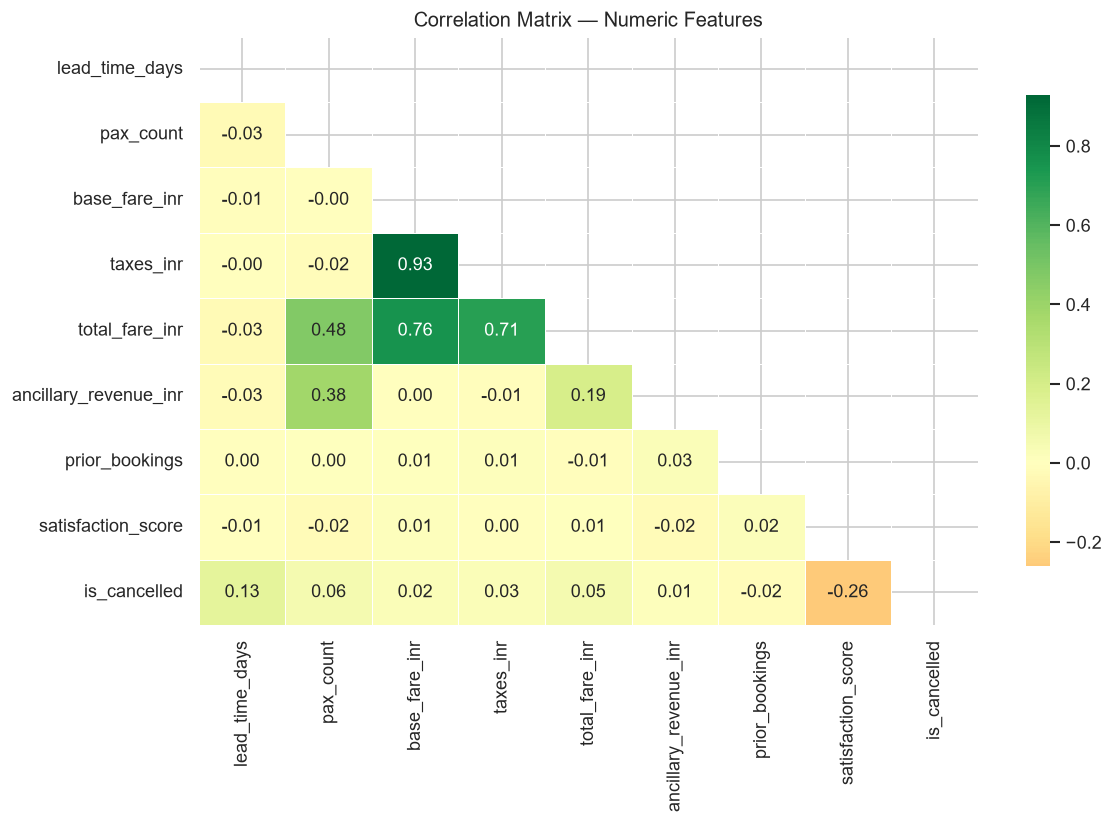

In [19]:
# Correlation heatmap of numeric features
numeric_cols = ['lead_time_days','pax_count','base_fare_inr','taxes_inr',
                'total_fare_inr','ancillary_revenue_inr','prior_bookings',
                'satisfaction_score','is_cancelled']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()


---
## 7. 📝 Business Recommendations Summary

*(200–300 words — written for the Clarity Operations Team)*

---

### Top 3 Business Recommendations

**1. 🎯 Target High-Risk Cancellation Segments Proactively**

The analysis reveals that bookings with long lead times (>90 days), high fare amounts, and made through the B2C Website channel carry the highest cancellation rates. First-class and business-class bookings, despite contributing a disproportionate share of total revenue, show elevated cancellation rates — representing significant potential revenue leakage. Clarity should implement an automated early-warning system that flags high-risk bookings (long lead time + premium cabin) within 24 hours of booking and triggers proactive retention communication — such as flexible change offers or personalised re-confirmation emails — before the customer initiates a cancellation.

**2. 📈 Prioritise NDC Channel Growth Over GDS**

NDC bookings generate higher average fares and significantly higher ancillary revenue per booking compared to GDS. As NDC adoption grows across the airline industry, Clarity should accelerate its NDC partnerships with top-performing airlines (particularly those in the high-revenue bracket) and shift B2B agent incentives toward NDC-sourced bookings. Even a 10% migration of GDS volume to NDC would meaningfully improve revenue per booking and margin.

**3. 🔁 Invest in Repeat Customer Retention Programmes**

Repeat customers (prior_bookings > 0) show higher average fares and better satisfaction scores, yet constitute a smaller share of the total booking base. The data clearly shows that retaining customers pays off — they book higher-value tickets and are less likely to cancel. Clarity should introduce a structured loyalty or recognition programme (e.g., priority support, fare-lock privileges, exclusive deals) targeting customers after their first successful booking, with the goal of converting new customers into the high-value repeat segment.

---
*Analysis performed on 2,000 bookings | Booking period: 2025 | All figures in INR*
